In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

FEATURES_PATH = "../data/anime_features.csv"

anime_features = pd.read_csv(FEATURES_PATH)

print("Rows:", len(anime_features))
print("Columns:", len(anime_features.columns))

Rows: 16216
Columns: 19


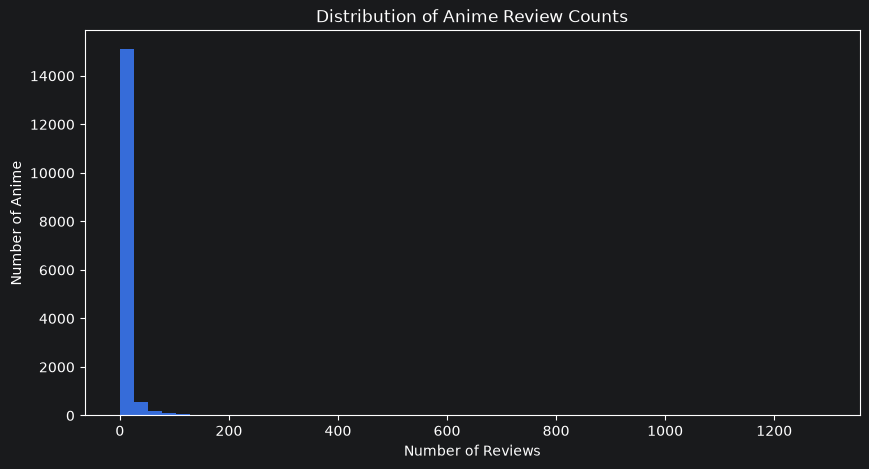

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(anime_features["review_count"], bins=50)

plt.xlabel("Number of Reviews")
plt.ylabel("Number of Anime")
plt.title("Distribution of Anime Review Counts")

plt.show()

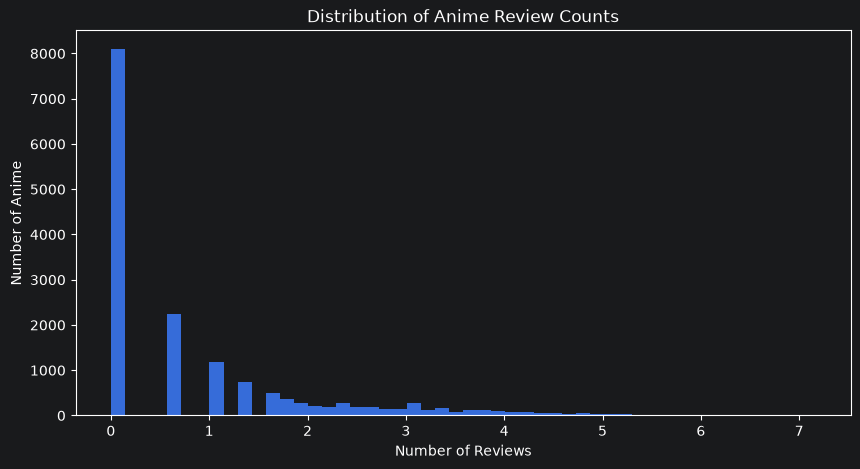

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(anime_features["log_review_count"], bins=50)

plt.xlabel("Number of Reviews")
plt.ylabel("Number of Anime")
plt.title("Distribution of Anime Review Counts")

plt.show()

In [5]:
top_reviewed = (
    anime_features[
        ["title", "review_count", "avg_review_score", "score"]
    ]
    .sort_values("review_count", ascending=False)
    .head(15)
)

top_reviewed

,title,review_count,avg_review_score,score
7882,Sword Art Online,1292.0,6.390093,7.49
740,Death Note,854.0,8.809133,8.65
773,Steins;Gate,779.0,8.976893,9.11
771,Kimi no Na wa.,718.0,8.662953,9.09
3,Fullmetal Alchemist: Brotherhood,637.0,9.243328,9.23
4900,School Days,636.0,6.106918,5.90
14,Clannad: After Story,597.0,9.195980,8.97
590,Toradora!,570.0,8.635088,8.34
654,Mahou Shoujo Madoka★Magica,565.0,8.693805,8.42
3348,Elfen Lied,548.0,7.220803,7.69


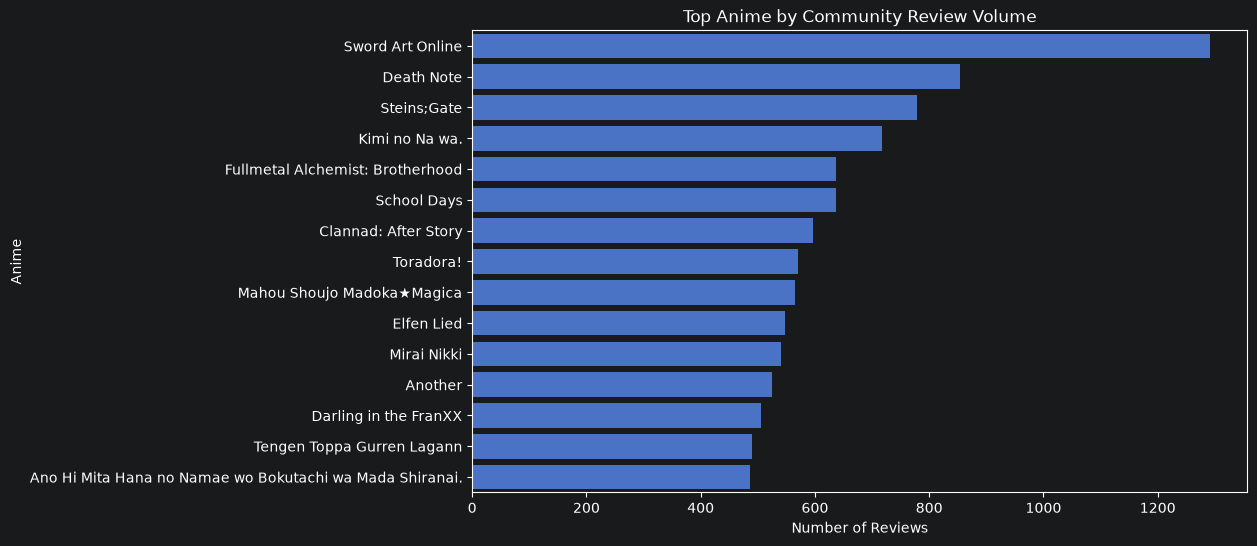

In [6]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_reviewed,
    x="review_count",
    y="title"
)

plt.xlabel("Number of Reviews")
plt.ylabel("Anime")
plt.title("Top Anime by Community Review Volume")

plt.show()

In [7]:
reviewed_anime = anime_features[
    anime_features["review_count"] >= 10
].copy()

print("Anime with at least 10 reviews:", len(reviewed_anime))

Anime with at least 10 reviews: 2266


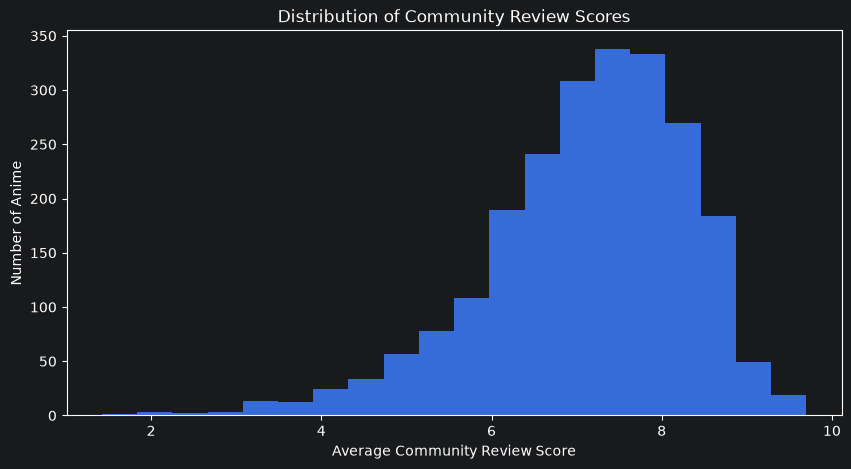

In [8]:
plt.figure(figsize=(10, 5))

plt.hist(
    reviewed_anime["avg_review_score"],
    bins=20
)

plt.xlabel("Average Community Review Score")
plt.ylabel("Number of Anime")
plt.title("Distribution of Community Review Scores")

plt.show()

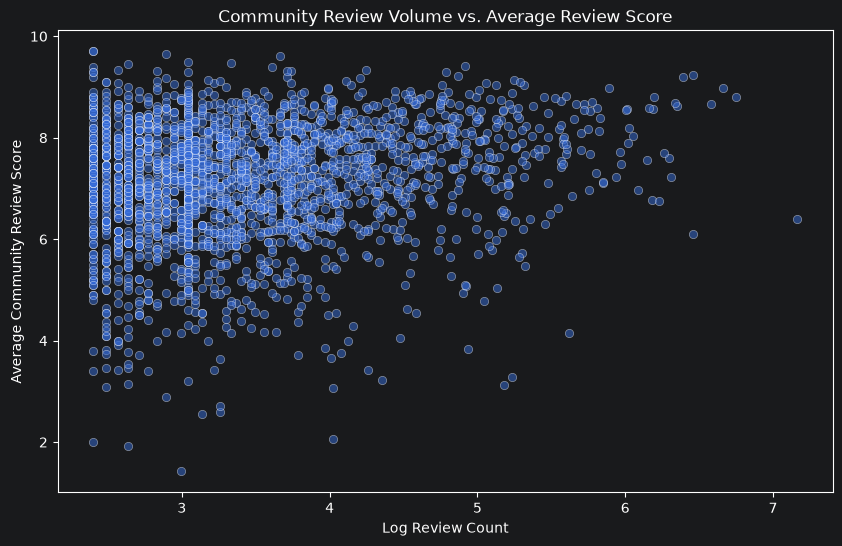

In [9]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=reviewed_anime,
    x="log_review_count",
    y="avg_review_score",
    alpha=0.5
)

plt.xlabel("Log Review Count")
plt.ylabel("Average Community Review Score")
plt.title("Community Review Volume vs. Average Review Score")

plt.show()

In [10]:
reviewed_anime[
    ["log_review_count", "avg_review_score"]
].corr()

,log_review_count,avg_review_score
log_review_count,1.000000,0.176221
avg_review_score,0.176221,1.000000


In [11]:
reviewed_anime["review_volume_group"] = pd.cut(
    reviewed_anime["review_count"],
    bins=[9, 20, 50, 100, 500, float("inf")],
    labels=["10–20", "21–50", "51–100", "101–500", "500+"]
)

reviewed_anime.groupby(
    "review_volume_group",
    observed=True
)["abs_score_difference"].mean()

review_volume_group
10–20      0.647984
21–50      0.554014
51–100     0.495910
101–500    0.431394
500+       0.323224
Name: abs_score_difference, dtype: float64

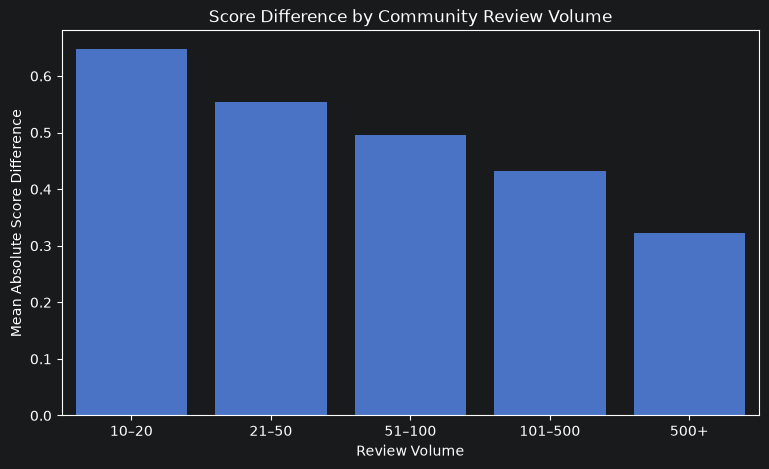

In [12]:
score_diff_by_volume = (
    reviewed_anime
    .groupby("review_volume_group", observed=True)["abs_score_difference"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=score_diff_by_volume,
    x="review_volume_group",
    y="abs_score_difference"
)

plt.xlabel("Review Volume")
plt.ylabel("Mean Absolute Score Difference")
plt.title("Score Difference by Community Review Volume")

plt.show()

Anime with at least 2 reviews: 5870


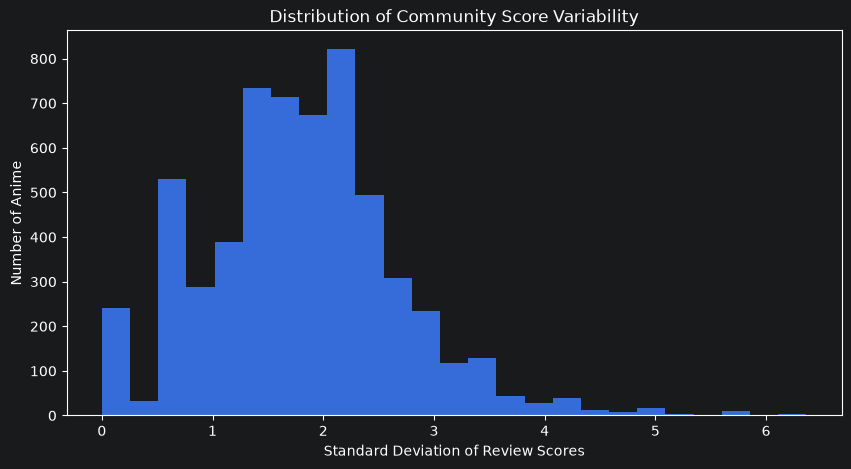

In [13]:
score_variability = anime_features[
    anime_features["review_count"] >= 2
].copy()

print("Anime with at least 2 reviews:", len(score_variability))

plt.figure(figsize=(10, 5))

plt.hist(
    score_variability["score_std"].dropna(),
    bins=25
)

plt.xlabel("Standard Deviation of Review Scores")
plt.ylabel("Number of Anime")
plt.title("Distribution of Community Score Variability")

plt.show()

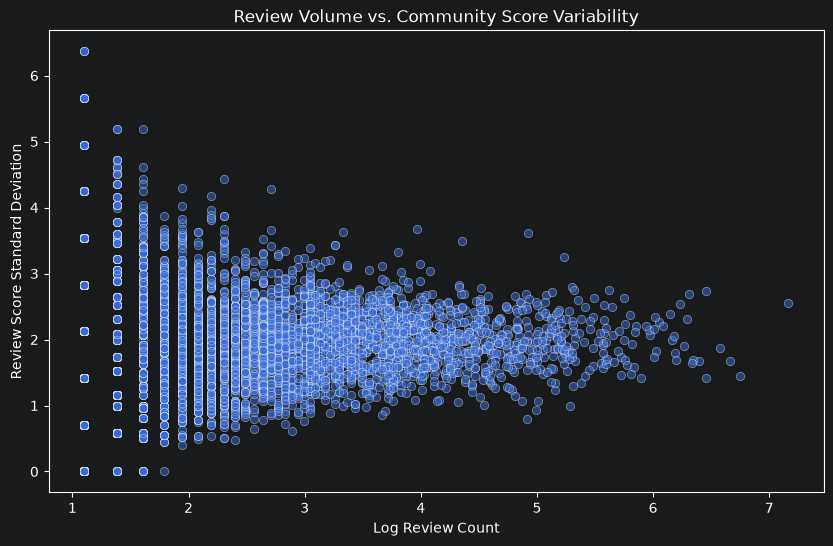

In [14]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=score_variability,
    x="log_review_count",
    y="score_std",
    alpha=0.5
)

plt.xlabel("Log Review Count")
plt.ylabel("Review Score Standard Deviation")
plt.title("Review Volume vs. Community Score Variability")

plt.show()

In [15]:
score_variability[
    ["log_review_count", "score_std"]
].corr()

,log_review_count,score_std
log_review_count,1.000000,0.174568
score_std,0.174568,1.000000


In [16]:
most_variable = (
    reviewed_anime[
        ["title", "review_count", "avg_review_score", "score_std"]
    ]
    .sort_values("score_std", ascending=False)
    .head(10)
)

most_variable

,title,review_count,avg_review_score,score_std
7113,Yo! Daitouryou Trap-kun,14.0,6.000000,4.278749
8942,Shitcom,52.0,3.846154,3.680285
7239,Kakugo no Susume,14.0,5.214286,3.662252
7200,Issho ni Sleeping: Sleeping with Hinako,27.0,4.703704,3.635454
2748,Boku no Pico,136.0,5.080882,3.621040
7598,Legend of Duo,13.0,3.538462,3.526457
8938,Tenkuu Danzai Skelter+Heaven,77.0,3.220779,3.496703
7128,Byston Well Monogatari: Garzey no Tsubasa,25.0,3.640000,3.438507
2199,Okane ga Nai,25.0,5.200000,3.427827
7097,Mahou Shoujo? Naria☆Girls,14.0,4.571429,3.412968


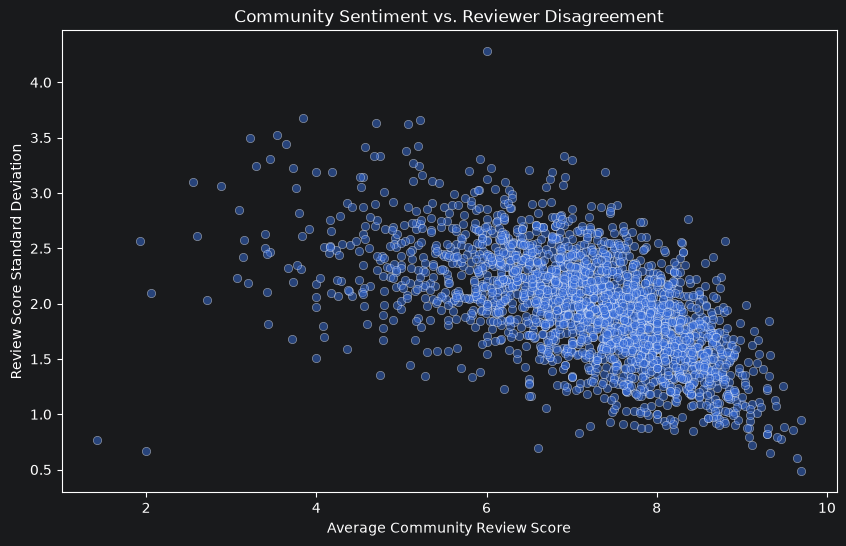

In [17]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=reviewed_anime,
    x="avg_review_score",
    y="score_std",
    alpha=0.5
)

plt.xlabel("Average Community Review Score")
plt.ylabel("Review Score Standard Deviation")
plt.title("Community Sentiment vs. Reviewer Disagreement")

plt.show()

In [18]:
reviewed_anime[
    ["avg_review_score", "score_std"]
].corr()

,avg_review_score,score_std
avg_review_score,1.000000,-0.580116
score_std,-0.580116,1.000000


In [19]:
community_features = [
    "review_count",
    "log_review_count",
    "avg_review_score",
    "score_std",
    "has_reviews",
    "score_difference",
    "abs_score_difference"
]

anime_features[community_features].corr()

,review_count,log_review_count,avg_review_score,score_std,has_reviews,score_difference,abs_score_difference
review_count,1.000000,0.620859,0.114291,0.075172,0.238702,-0.054815,-0.178323
log_review_count,0.620859,1.000000,0.160285,0.174568,0.737822,-0.113385,-0.372272
avg_review_score,0.114291,0.160285,1.000000,-0.318608,NaN,0.832749,-0.168297
score_std,0.075172,0.174568,-0.318608,1.000000,NaN,-0.284145,-0.032613
has_reviews,0.238702,0.737822,NaN,NaN,1.000000,NaN,NaN
score_difference,-0.054815,-0.113385,0.832749,-0.284145,NaN,1.000000,0.001181
abs_score_difference,-0.178323,-0.372272,-0.168297,-0.032613,NaN,0.001181,1.000000


In [20]:
top_rated = (
    anime_features[
        anime_features["review_count"] >= 50
    ][
        ["title", "review_count", "avg_review_score", "score"]
    ]
    .sort_values("avg_review_score", ascending=False)
    .head(15)
)

top_rated

,title,review_count,avg_review_score,score
739,Suzumiya Haruhi no Shoushitsu,135.0,9.414815,8.68
766,3-gatsu no Lion 2nd Season,69.0,9.333333,9.02
726,Ansatsu Kyoushitsu 2nd Season,119.0,9.294118,8.60
3,Fullmetal Alchemist: Brotherhood,637.0,9.243328,9.23
761,Hajime no Ippo,129.0,9.224806,8.77
14,Clannad: After Story,597.0,9.195980,8.97
755,Rurouni Kenshin: Meiji Kenkaku Romantan - Tsui...,66.0,9.181818,8.75
13,Gintama,189.0,9.137566,8.97
706,Mo Dao Zu Shi,60.0,9.116667,8.53
735,Haikyuu!!,197.0,9.101523,8.62


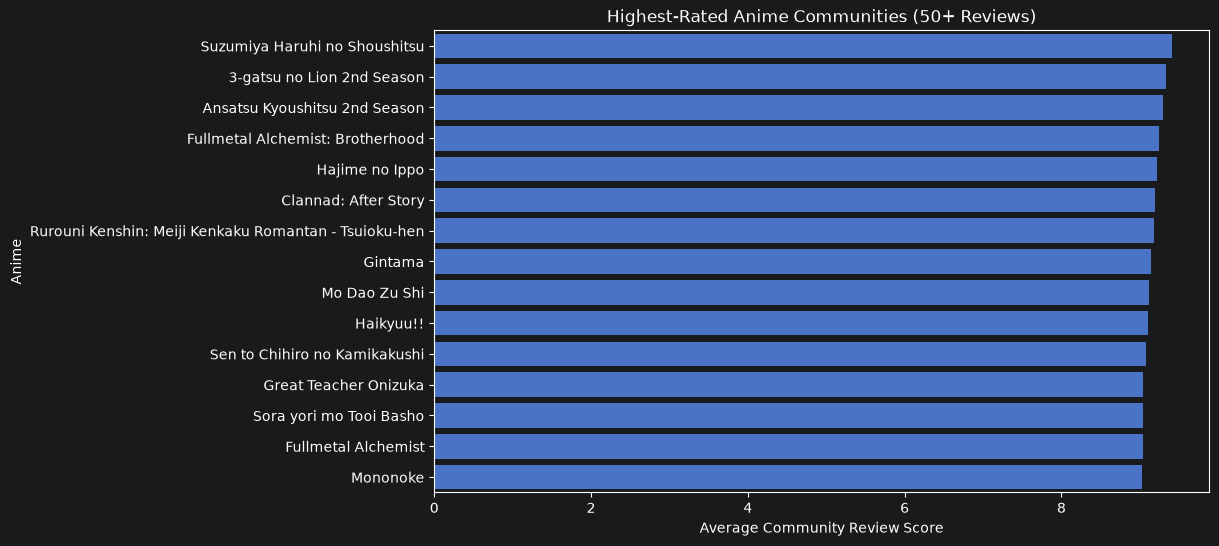

In [21]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_rated,
    x="avg_review_score",
    y="title"
)

plt.xlabel("Average Community Review Score")
plt.ylabel("Anime")
plt.title("Highest-Rated Anime Communities (50+ Reviews)")

plt.show()

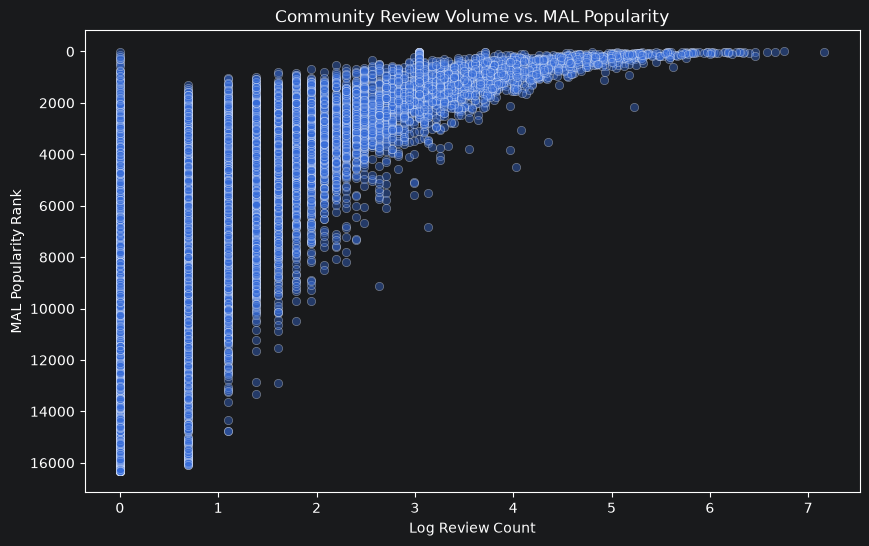

In [22]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=anime_features,
    x="log_review_count",
    y="popularity",
    alpha=0.4
)

plt.xlabel("Log Review Count")
plt.ylabel("MAL Popularity Rank")
plt.title("Community Review Volume vs. MAL Popularity")

plt.gca().invert_yaxis()

plt.show()

anime with more reviews generally have a better MAL popularity rank ( lower rank = more popular).

In [23]:
anime_features[
    ["log_review_count", "popularity"]
].corr()

,log_review_count,popularity
log_review_count,1.00000,-0.76812
popularity,-0.76812,1.00000


In [24]:
correlation = anime_features[
    ["log_review_count", "members"]
].corr().iloc[0, 1]

print(f"Correlation: {correlation:.3f}")

Correlation: 0.648


In [25]:
correlation = anime_features[
    ["log_review_count", "score"]
].corr().iloc[0, 1]

print(f"Correlation: {correlation:.3f}")

Correlation: 0.513


In [26]:
correlation_summary = pd.DataFrame({
    "Relationship": [
        "Review volume vs. MAL popularity",
        "Review volume vs. MAL members",
        "Review volume vs. MAL score",
        "Community score vs. score variability"
    ],
    "Correlation": [
        -0.76,
        0.648,
        0.513,
        -0.58
    ]
})

correlation_summary

,Relationship,Correlation
0,Review volume vs. MAL popularity,-0.760
1,Review volume vs. MAL members,0.648
2,Review volume vs. MAL score,0.513
3,Community score vs. score variability,-0.580


### Key Correlation Findings

The correlation analysis shows that community review volume is strongly associated with MAL popularity, with a correlation of **-0.76**. Since a lower MAL popularity rank represents greater popularity, this negative correlation indicates that more-reviewed anime tend to be more popular.

Review volume also has a moderately strong positive relationship with **MAL members (0.648)** and a moderate positive relationship with **MAL score (0.513)**. This suggests that larger audiences tend to generate more community engagement and are somewhat more likely to have higher ratings.

Finally, **community score and score variability have a -0.58 correlation**, indicating that higher-rated anime generally show less disagreement among reviewers. Overall, community engagement, audience size, and sentiment are related, but they represent different aspects of an anime's community momentum.

In [27]:
anime_features["genre"].head()

0    ['Comedy', 'Sports', 'Drama', 'School', 'Shoun...
1    ['Drama', 'Music', 'Romance', 'School', 'Shoun...
2    ['Sci-Fi', 'Adventure', 'Mystery', 'Drama', 'F...
3    ['Action', 'Military', 'Adventure', 'Comedy', ...
4     ['Action', 'Mystery', 'Supernatural', 'Vampire']
Name: genre, dtype: str

In [28]:
import ast

anime_features["genre_list"] = anime_features["genre"].apply(
    ast.literal_eval
)

anime_features[["title", "genre", "genre_list"]].head()

,title,genre,genre_list
0,Haikyuu!! Second Season,"['Comedy', 'Sports', 'Drama', 'School', 'Shoun...","[Comedy, Sports, Drama, School, Shounen]"
1,Shigatsu wa Kimi no Uso,"['Drama', 'Music', 'Romance', 'School', 'Shoun...","[Drama, Music, Romance, School, Shounen]"
2,Made in Abyss,"['Sci-Fi', 'Adventure', 'Mystery', 'Drama', 'F...","[Sci-Fi, Adventure, Mystery, Drama, Fantasy]"
3,Fullmetal Alchemist: Brotherhood,"['Action', 'Military', 'Adventure', 'Comedy', ...","[Action, Military, Adventure, Comedy, Drama, M..."
4,Kizumonogatari III: Reiketsu-hen,"['Action', 'Mystery', 'Supernatural', 'Vampire']","[Action, Mystery, Supernatural, Vampire]"


In [29]:
genre_df = anime_features[
    ["uid", "title", "genre_list", "review_count", "avg_review_score"]
].explode("genre_list")

genre_df.head(10)

,uid,title,genre_list,review_count,avg_review_score
0,28891,Haikyuu!! Second Season,Comedy,52.0,8.788462
0,28891,Haikyuu!! Second Season,Sports,52.0,8.788462
0,28891,Haikyuu!! Second Season,Drama,52.0,8.788462
0,28891,Haikyuu!! Second Season,School,52.0,8.788462
0,28891,Haikyuu!! Second Season,Shounen,52.0,8.788462
1,23273,Shigatsu wa Kimi no Uso,Drama,20.0,6.450000
1,23273,Shigatsu wa Kimi no Uso,Music,20.0,6.450000
1,23273,Shigatsu wa Kimi no Uso,Romance,20.0,6.450000
1,23273,Shigatsu wa Kimi no Uso,School,20.0,6.450000
1,23273,Shigatsu wa Kimi no Uso,Shounen,20.0,6.450000


In [30]:
genre_counts = (
    genre_df["genre_list"]
    .value_counts()
    .reset_index()
)

genre_counts.columns = ["genre", "anime_count"]

genre_counts.head(15)

,genre,anime_count
0,Comedy,5640
1,Action,3572
2,Fantasy,2971
3,Adventure,2753
4,Sci-Fi,2462
5,Kids,2458
6,Drama,2457
7,Shounen,1915
8,Music,1863
9,Romance,1762


In [31]:
genre_engagement = (
    genre_df
    .groupby("genre_list")["review_count"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

genre_engagement

genre_list
Thriller         64.216667
Psychological    42.046584
Mystery          25.903561
Harem            25.425134
Vampire          24.111111
Supernatural     22.911635
Romance          22.738933
Horror           21.262673
Shoujo Ai        20.671233
School           20.175495
Super Power      18.698333
Drama            16.895808
Game             16.712644
Ecchi            15.918919
Josei            15.688172
Name: review_count, dtype: float64

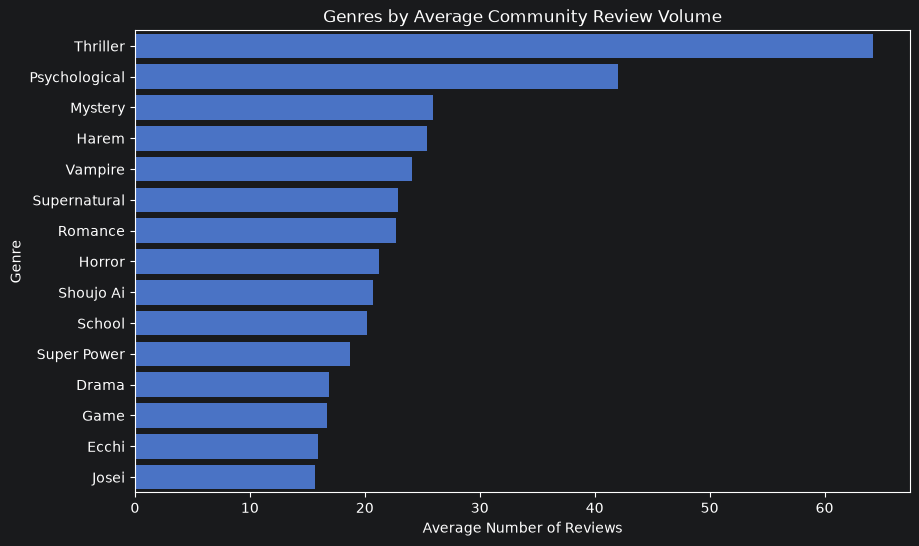

In [32]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=genre_engagement.reset_index(),
    x="review_count",
    y="genre_list"
)

plt.xlabel("Average Number of Reviews")
plt.ylabel("Genre")
plt.title("Genres by Average Community Review Volume")
plt.show()

In [44]:
genre_median_reviews = (
    genre_df
    .groupby("genre_list")["review_count"]
    .median()
    .sort_values(ascending=False)
    .head(15)
)

genre_median_reviews

genre_list
Shoujo Ai        12.0
Thriller          9.5
Psychological     8.0
Harem             7.5
Vampire           6.0
Yaoi              5.5
Josei             4.0
Romance           4.0
Mystery           4.0
Ecchi             4.0
Shounen Ai        4.0
Horror            3.0
Military          3.0
Supernatural      3.0
School            3.0
Name: review_count, dtype: float64

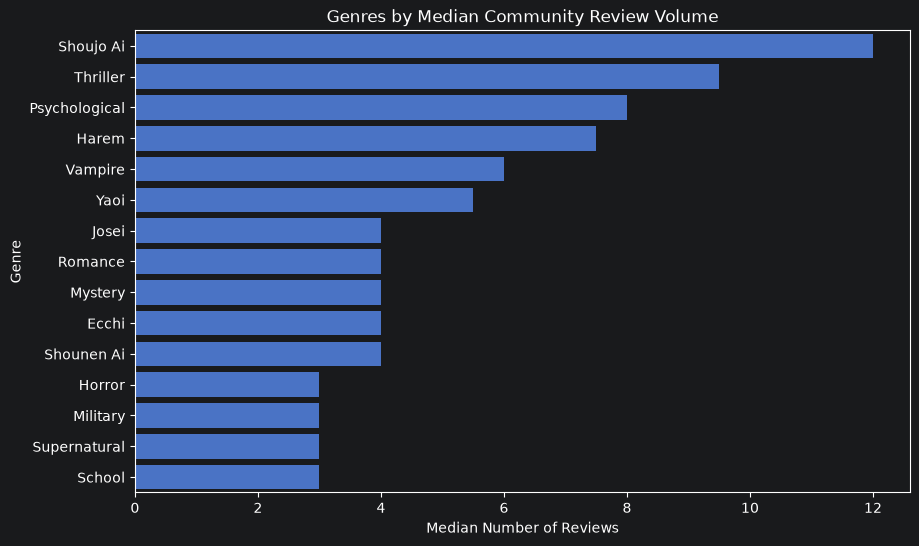

In [45]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=genre_median_reviews.reset_index(),
    x="review_count",
    y="genre_list"
)

plt.xlabel("Median Number of Reviews")
plt.ylabel("Genre")
plt.title("Genres by Median Community Review Volume")
plt.show()

In [47]:
genre_summary = pd.DataFrame({
    "anime_count": genre_counts.set_index("genre")["anime_count"],
    "mean_reviews": genre_engagement,
    "median_reviews": genre_median_reviews
})

genre_summary.sort_values(
    "median_reviews",
    ascending=False
).head(15)

,anime_count,mean_reviews,median_reviews
Shoujo Ai,73,20.671233,12.0
Thriller,120,64.216667,9.5
Psychological,322,42.046584,8.0
Harem,374,25.425134,7.5
Vampire,135,24.111111,6.0
Yaoi,40,NaN,5.5
Ecchi,740,15.918919,4.0
Romance,1762,22.738933,4.0
Shounen Ai,91,NaN,4.0
Josei,93,15.688172,4.0


In [48]:
GENRE_PATH = "../data/genre_summary.csv"

genre_summary.to_csv(GENRE_PATH)

print("Saved:", GENRE_PATH)

Saved: ../data/genre_summary.csv


In [49]:
eda_features = [
    "review_count",
    "log_review_count",
    "members",
    "popularity",
    "score",
    "avg_review_score",
    "score_std"
]

correlation_matrix = anime_features[eda_features].corr()

correlation_matrix

,review_count,log_review_count,members,popularity,score,avg_review_score,score_std
review_count,1.000000,0.620859,0.827739,-0.350250,0.290458,0.114291,0.075172
log_review_count,0.620859,1.000000,0.647989,-0.768120,0.512878,0.160285,0.174568
members,0.827739,0.647989,1.000000,-0.439864,0.391430,0.153187,0.059363
popularity,-0.350250,-0.768120,-0.439864,1.000000,-0.661148,-0.280870,-0.055733
score,0.290458,0.512878,0.391430,-0.661148,1.000000,0.576152,-0.166148
avg_review_score,0.114291,0.160285,0.153187,-0.280870,0.576152,1.000000,-0.318608
score_std,0.075172,0.174568,0.059363,-0.055733,-0.166148,-0.318608,1.000000


### Final EDA Findings

The EDA shows that community engagement is strongly related to existing MAL audience metrics. Review volume has a strong negative correlation with MAL popularity rank (-0.768), meaning anime with more reviews tend to have better popularity rankings. Review volume is also strongly associated with the number of MAL members (0.648 for log review count and 0.828 for raw review count).

Community engagement also shows a moderate positive relationship with MAL score (0.513 using log review count). The average score given by reviewers has a moderate positive relationship with the overall MAL score (0.576), while community score and reviewer score variability have a negative relationship (-0.319).

Overall, the analysis suggests that review volume, audience size, popularity, and community sentiment are related but represent different dimensions of community momentum. These relationships are associations rather than evidence of causation.